# Cloning Test ZI

This notebook traces the VDP cloning path from S3M orbital-element tables to visible `(v_lambda, v_beta)` points and density-map smoothing diagnostics.

`clone_visible_df`: contains the cloned orbital elements and the velocity-map coordinates used in the plots.

## 0. Imports and Settings

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

NEOMOD_DIR = Path.cwd().resolve()
if not (NEOMOD_DIR / 'src' / 'velocity_density_pipeline.py').exists():
    NEOMOD_DIR = NEOMOD_DIR.parent.parent  # notebooks/dev -> notebooks -> neomod
if not (NEOMOD_DIR / 'src' / 'velocity_density_pipeline.py').exists():
    NEOMOD_DIR = Path('/Users/devanshisingh/Downloads/research/NEO_probability/neomod')
sys.path.insert(0, str(NEOMOD_DIR / 'src'))

import velocity_density_pipeline as vdp

print('Using VDP:', Path(vdp.__file__).resolve())

Using VDP: /Users/ivezic/Work/Science/SolarSystem/NEO-Devanshi/neomod/src/velocity_density_pipeline.py


In [2]:
OBSTIME_STR = '2026-05-09T22:00:00'
CENTER_LON_DEG = 229.0
CENTER_LAT_DEG = 0.0
MAX_SEP_DEG = 30.0

# For testing: increase these later
POP_TO_TEST = 'NEO'
MAX_SOURCE_OBJECTS = 5000
MAG_BIN_TO_TEST = 'mag21'
# Keep False for the dense baseline cloning diagnostic. Set True to test one mag bin only.
USE_MAG_BIN_FOR_CLONING = False
CLONE_FACTOR_TEST = 30
RNG_SEED = 42

# Density-map controls for the diagnostic section.
GRID_LIM = (-0.8, 0.8)
GRID_STEP = 0.02
K_MAP_TEST = 10
N_D0_GRID_TEST = 120

# Match the current production NEO smoothing behavior.
SMOOTH_PASSES = [
    {'support_threshold': 3.0, 'sigma_pixels': 1.5, 'truncate_sigma': 5.0},
    {'support_threshold': 10.0, 'sigma_pixels': 4.0, 'truncate_sigma': 5.0},
]
SCALE_SUPPORT_BY_CLONE_FACTOR = True

rng = np.random.default_rng(RNG_SEED)

## 1. Load S3M Populations

Each loaded DataFrame contains the S3M orbital elements plus a derived semi-major axis column `a`.

In [238]:
print('Loading MBA...')
df_mba, scorer_mba = vdp.load_s3m_population('mba', verbose=True)

print('\nLoading NEO...')
df_neo, scorer_neo = vdp.load_s3m_population('neo', verbose=True)

print('\nLoading TNO...')
df_tno, scorer_tno = vdp.load_s3m_population('tno', verbose=True)

print('\nLoading Trojans...')
df_trojan, scorer_trojan = vdp.load_s3m_population('trojan', verbose=True)

population_dfs = {
    'MBA': df_mba,
    'NEO': df_neo,
    'TNO': df_tno,
    'Trojans': df_trojan,
}
population_scorers = {
    'MBA': scorer_mba,
    'NEO': scorer_neo,
    'TNO': scorer_tno,
    'Trojans': scorer_trojan,
}

pd.DataFrame({name: {'rows': len(df), 'columns': len(df.columns)} for name, df in population_dfs.items()}).T

Loading MBA...
Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/S1_00.s3m', 'S3Mdata/S1_01.s3m', 'S3Mdata/S1_02.s3m', 'S3Mdata/S1_03.s3m', 'S3Mdata/S1_04.s3m', 'S3Mdata/S1_05.s3m', 'S3Mdata/S1_06.s3m', 'S3Mdata/S1_07.s3m', 'S3Mdata/S1_08.s3m', 'S3Mdata/S1_09.s3m', 'S3Mdata/S1_10.s3m', 'S3Mdata/S1_11.s3m', 'S3Mdata/S1_12.s3m', 'S3Mdata/S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.

Loading NEO...
Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.

Loading TNO...
Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.

Loading Trojans...
Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['S3Mdata/St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.

,rows,columns
MBA,13883361,15
NEO,268511,15
TNO,48682,15
Trojans,179882,15


## 2. Access Orbital Elements in the DataFrames

In [4]:
ORBIT_COLS = ['OID', 'a', 'q', 'e', 'i', 'node', 'argperi', 't_p', 'H']

df = population_dfs[POP_TO_TEST]
print('Columns in selected population:')
print(list(df.columns))

df[ORBIT_COLS].head()

Columns in selected population:
['OID', 'FORMAT', 'q', 'e', 'i', 'node', 'argperi', 't_p', 'H', 't_0', 'INDEX', 'N_PAR', 'MOID', 'COMPCODE', 'a']


,OID,a,q,e,i,node,argperi,t_p,H
0,S0000001a,2.025814,1.251459,0.382244,9.304721,252.063850,185.610748,54067.969964,10.315
1,S0000002a,3.811219,1.286219,0.662518,18.303865,132.486568,80.463153,54670.088589,10.818
2,S0000003a,1.739907,0.617193,0.645272,10.302493,67.484378,182.131418,54522.349738,11.175
3,S0000004a,2.669612,0.383306,0.856419,16.988463,117.793282,242.430598,54973.510299,11.452
4,S0000005a,2.498139,0.569264,0.772125,22.761089,314.323204,73.119299,54075.567352,11.678


In [5]:
df[ORBIT_COLS].describe().T

,count,mean,std,min,25%,50%,75%,max
a,268511.0,1.959882,0.705068,0.309999,1.451172,1.976464,2.420834,7.344929
q,268511.0,0.763699,0.340929,0.000404,0.497479,0.790870,1.059862,1.299996
e,268511.0,0.588102,0.187509,0.001983,0.461965,0.592353,0.725975,0.999457
i,268511.0,23.683501,17.126926,0.002902,10.094004,18.885782,33.587569,89.814587
node,268511.0,179.936817,103.803305,0.001529,90.003376,180.087413,269.678785,359.997723
argperi,268511.0,180.035285,103.802307,0.001371,90.481505,179.943199,270.014456,359.999636
t_p,268511.0,54466.457094,343.834508,51324.705697,54258.591858,54466.256086,54675.469382,57895.304070
H,268511.0,23.759334,1.240541,10.315000,23.280000,24.140000,24.643000,25.000000


## 3. Select a Test Sample

The full S3M files can be large. The following cells use a smaller subset for testing.

In [6]:
source_df_full = population_dfs[POP_TO_TEST].copy().reset_index(drop=True)

if MAX_SOURCE_OBJECTS is not None and len(source_df_full) > MAX_SOURCE_OBJECTS:
    sample_idx = rng.choice(len(source_df_full), size=MAX_SOURCE_OBJECTS, replace=False)
    source_df_sample = source_df_full.iloc[sample_idx].copy().reset_index(drop=True)
else:
    source_df_sample = source_df_full.copy().reset_index(drop=True)

source_df_sample['source_row'] = np.arange(len(source_df_sample), dtype=int)
source_df = source_df_sample.copy()

print(f'{POP_TO_TEST}: sampled {len(source_df_sample):,} source objects')
source_df_sample[ORBIT_COLS + ['source_row']].head()

NEO: sampled 5,000 source objects


,OID,a,q,e,i,node,argperi,t_p,H,source_row
0,S0000e5La,1.032104,0.873167,0.153994,19.698511,319.687247,325.910626,54585.654198,22.980,0
1,S00015uxa,1.906857,1.197672,0.371913,2.800536,192.580835,333.708763,54870.151972,24.923,1
2,S0000g3ha,1.329042,0.606291,0.543813,84.694611,159.903715,303.483375,54476.123773,23.141,2
3,S0000hB9a,2.133839,0.350374,0.835801,20.211003,83.162417,275.203412,54041.578723,23.255,3
4,S0000M7Va,5.211405,0.871733,0.832726,16.283101,167.474998,131.097383,55791.825144,24.504,4


## 4. Apparent-Magnitude Bin Split

Production VDP maps are generated separately by apparent-magnitude bin. This section attaches `mag_app`, counts the bins, and can restrict the cloning test to one bin (optional).

In [7]:
scorer = population_scorers[POP_TO_TEST]

mag_app = vdp.compute_apparent_magnitude_for_population(
    df=source_df_sample,
    obstime_str=OBSTIME_STR,
    scorer=scorer,
    chunk=50_000,
    show_progress=True,
)

source_df_with_mag = source_df_sample.copy()
source_df_with_mag['mag_app'] = mag_app

def assign_mag_bin(mag):
    if not np.isfinite(mag):
        return None
    for mb in vdp.DEFAULT_MAG_BINS:
        if mb['mag_min'] <= mag < mb['mag_max']:
            return mb['label']
    return None

source_df_with_mag['mag_bin_label'] = [assign_mag_bin(m) for m in source_df_with_mag['mag_app']]

bin_summary = []
for mb in vdp.DEFAULT_MAG_BINS:
    in_bin = source_df_with_mag['mag_bin_label'] == mb['label']
    bin_summary.append({
        'label': mb['label'],
        'mag_min': mb['mag_min'],
        'mag_max': mb['mag_max'],
        'n_sample': int(in_bin.sum()),
    })
bin_summary.append({
    'label': 'outside_bins',
    'mag_min': np.nan,
    'mag_max': np.nan,
    'n_sample': int(source_df_with_mag['mag_bin_label'].isna().sum()),
})

pd.DataFrame(bin_summary)

Propagate with newton: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 558.35it/s]


,label,mag_min,mag_max,n_sample
0,14_16,14.0,16.0,0
1,16_18,16.0,18.0,1
2,18_20,18.0,20.0,6
3,mag20,20.0,21.0,13
4,mag21,21.0,22.0,20
5,mag22,22.0,23.0,48
6,mag23,23.0,24.0,117
7,mag24+,24.0,25.0,212
8,outside_bins,NaN,NaN,4583


In [8]:
magbin_source_df = source_df_with_mag[
    source_df_with_mag['mag_bin_label'] == MAG_BIN_TO_TEST
].copy().reset_index(drop=True)

print(f'Magnitude bin selected: {MAG_BIN_TO_TEST}')
print('Rows in selected bin:', len(magbin_source_df))

if USE_MAG_BIN_FOR_CLONING:
    if len(magbin_source_df) == 0:
        raise ValueError(f'No sampled objects in magnitude bin {MAG_BIN_TO_TEST!r}. Increase MAX_SOURCE_OBJECTS or choose another bin.')
    source_df = magbin_source_df.copy()
    print('Cloning input restricted to selected magnitude bin.')
    if len(source_df) < 200:
        print('Warning: selected bin has few sampled source rows; velocity plots may look sparse. Increase MAX_SOURCE_OBJECTS or CLONE_FACTOR_TEST for a denser test.')
else:
    source_df = source_df_with_mag.copy()
    print('Cloning input uses the full sampled source table. The magnitude-bin table above is for inspection.')

display_cols = ORBIT_COLS + ['source_row', 'mag_app', 'mag_bin_label']
source_df[display_cols].head(15)

Magnitude bin selected: mag21
Rows in selected bin: 20
Cloning input uses the full sampled source table. The magnitude-bin table above is for inspection.


,OID,a,q,e,i,node,argperi,t_p,H,source_row,mag_app,mag_bin_label
0,S0000e5La,1.032104,0.873167,0.153994,19.698511,319.687247,325.910626,54585.654198,22.980,0,25.376182,None
1,S00015uxa,1.906857,1.197672,0.371913,2.800536,192.580835,333.708763,54870.151972,24.923,1,30.399782,None
2,S0000g3ha,1.329042,0.606291,0.543813,84.694611,159.903715,303.483375,54476.123773,23.141,2,24.803092,mag24+
3,S0000hB9a,2.133839,0.350374,0.835801,20.211003,83.162417,275.203412,54041.578723,23.255,3,29.207815,None
4,S0000M7Va,5.211405,0.871733,0.832726,16.283101,167.474998,131.097383,55791.825144,24.504,4,33.987859,None
5,S0000TiNa,2.462124,0.235899,0.904189,33.804284,46.583328,193.319432,54512.210800,24.676,5,31.626617,None
6,S0000HBVa,1.689137,1.246675,0.261946,43.204370,72.287524,12.019280,54141.023505,24.381,6,28.490659,None
7,S00002Tya,1.820014,0.293429,0.838776,12.447192,104.095386,337.521874,54469.611805,21.016,7,26.384400,None
8,S0000RO1a,3.067356,1.170745,0.618321,15.102691,20.697528,82.489849,55023.256411,24.642,8,28.592030,None
9,S0000HTMa,2.795065,0.931422,0.666762,12.706890,93.801389,326.375421,53656.260157,24.389,9,30.687203,None


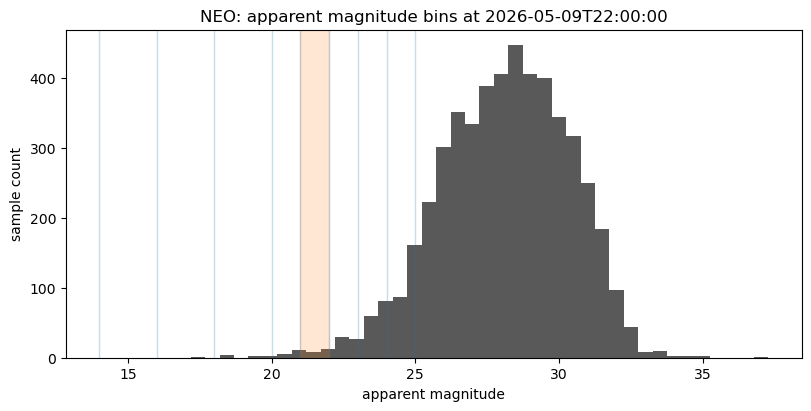

In [9]:
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
finite_mag = np.isfinite(source_df_with_mag['mag_app'])
ax.hist(source_df_with_mag.loc[finite_mag, 'mag_app'], bins=40, color='0.35')

for mb in vdp.DEFAULT_MAG_BINS:
    ax.axvline(mb['mag_min'], color='tab:blue', alpha=0.25, lw=1)
ax.axvline(vdp.DEFAULT_MAG_BINS[-1]['mag_max'], color='tab:blue', alpha=0.25, lw=1)

selected_mbin = next(mb for mb in vdp.DEFAULT_MAG_BINS if mb['label'] == MAG_BIN_TO_TEST)
ax.axvspan(selected_mbin['mag_min'], selected_mbin['mag_max'], color='tab:orange', alpha=0.18)
ax.set_xlabel('apparent magnitude')
ax.set_ylabel('sample count')
ax.set_title(f'{POP_TO_TEST}: apparent magnitude bins at {OBSTIME_STR}')
plt.show()

## 5. Clone Orbital Elements Directly

`clone_population_conditional_K_from_M` returns cloned orbital-element arrays. The test table below helps in checking the clone inputs after propagation.

In [10]:
a_rep, e_rep, inc_rep, node_rep, argperi_rep, tp_rep, clone_diag = (
    vdp.clone_population_conditional_K_from_M(
        df=source_df,
        clone_factor=CLONE_FACTOR_TEST,
        obstime_str=OBSTIME_STR,
        rng=rng,
        return_diagnostics=True,
    )
)

parent_row = np.repeat(source_df['source_row'].to_numpy(), CLONE_FACTOR_TEST)
parent_oid = np.repeat(source_df['OID'].to_numpy(), CLONE_FACTOR_TEST)
parent_H = np.repeat(source_df['H'].to_numpy(dtype=float), CLONE_FACTOR_TEST)

raw_clone_df = pd.DataFrame({
    'parent_row': parent_row,
    'parent_OID': parent_oid,
    'a': a_rep.astype(float),
    'e': e_rep.astype(float),
    'i': inc_rep.astype(float),
    'node': node_rep.astype(float),
    'argperi': argperi_rep.astype(float),
    't_p': tp_rep.astype(float),
    'H': parent_H.astype(float),
})

print('Raw cloned orbital-element table:', raw_clone_df.shape)
raw_clone_df.head()

Raw cloned orbital-element table: (150000, 9)


,parent_row,parent_OID,a,e,i,node,argperi,t_p,H
0,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,0.774689,61025.480469,22.98
1,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,101.706398,61119.484375,22.98
2,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,316.707703,60936.945312,22.98
3,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,113.803650,60801.992188,22.98
4,0,S0000e5La,1.032104,0.153994,19.698511,319.687256,157.779068,60907.531250,22.98


In [11]:
#From the conditional K|M sampler.
pd.DataFrame({
    'M_parent_deg': clone_diag['M_parent_deg'][:10],
    'M_clone_deg': clone_diag['M_clone_deg'][:10],
    'K_clone_deg': clone_diag['K_clone_deg'][:10],
    'clone_bin': clone_diag['clone_bin'][:10],
})

,M_parent_deg,M_clone_deg,K_clone_deg,clone_bin
0,69.075501,135.768845,320.461945,13
1,198.040766,47.404860,61.393654,4
2,345.945260,218.988084,276.394966,21
3,93.978726,345.840208,73.490906,34
4,85.553633,246.635728,117.466324,24
5,258.493438,296.615774,263.691772,29
6,275.686148,192.572738,133.606262,19
7,169.593698,42.213611,2.289177,4
8,47.709002,264.168948,241.610176,26
9,144.774911,147.440479,90.085131,14


## 6. Propagate Clones to the Velocity-Map Coordinates

`build_visible_subset_dataframe` adds sky position, ecliptic coordinates, and angular velocity columns. The same DataFrame keeps the cloned orbital elements.

In [12]:
scorer = population_scorers[POP_TO_TEST]

clone_visible_df = vdp.build_visible_subset_dataframe(
    raw_clone_df,
    obstime_str=OBSTIME_STR,
    scorer=scorer,
    max_sep_deg=MAX_SEP_DEG,
    center_mode='custom_ecliptic',
    center_lon_deg=CENTER_LON_DEG,
    center_lat_deg=CENTER_LAT_DEG,
    chunk=50_000,
    show_progress=True,
)

print('Visible cloned table:', clone_visible_df.shape)
print('Columns:', list(clone_visible_df.columns))

Propagate with newton: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 74.88it/s]

Visible cloned table: (6867, 20)
Columns: ['parent_row', 'parent_OID', 'a', 'e', 'i', 'node', 'argperi', 't_p', 'H', 'ra_deg', 'dec_deg', 'dra_deg_day', 'ddec_deg_day', 'sky_sep_deg', 'lam_deg', 'beta_deg', 'vlam', 'vbeta', 'M_obs_deg', 'L_obs_deg']


In [13]:
MAP_INPUT_COLS = [
    'parent_row', 'parent_OID',
    'a', 'e', 'i', 'node', 'argperi', 't_p', 'H',
    'ra_deg', 'dec_deg', 'lam_deg', 'beta_deg', 'vlam', 'vbeta', 'sky_sep_deg',
]

clone_visible_df[MAP_INPUT_COLS].head(10)

,parent_row,parent_OID,a,e,i,node,argperi,t_p,H,ra_deg,dec_deg,lam_deg,beta_deg,vlam,vbeta,sky_sep_deg
0,1,S00015uxa,1.906857,0.371913,2.800535,192.580841,319.828491,61061.609375,24.923,236.381642,-14.565070,237.449508,5.156320,-0.330589,0.040811,9.885519
1,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,323.335327,60496.250000,23.255,236.203261,-5.490802,235.211507,13.960465,-0.279263,-0.009865,15.253297
2,4,S0000M7Va,5.211405,0.832726,16.283102,167.474991,244.980713,59971.253906,24.504,217.241745,0.220288,214.820153,14.137646,-0.113252,-0.004246,19.923217
3,4,S0000M7Va,5.211405,0.832726,16.283102,167.474991,251.383560,60305.328125,24.504,216.197453,0.753717,213.621845,14.297920,-0.129408,-0.005607,20.882568
4,4,S0000M7Va,5.211405,0.832726,16.283102,167.474991,226.489883,58777.855469,24.504,216.543017,0.021266,214.207232,13.720599,-0.098982,-0.003469,20.074249
5,4,S0000M7Va,5.211405,0.832726,16.283102,167.474991,205.254547,57991.554688,24.504,206.331510,1.808281,203.752558,11.847247,-0.106213,-0.006087,27.726407
6,4,S0000M7Va,5.211405,0.832726,16.283102,167.474991,213.944473,58615.363281,24.504,205.240023,1.672301,202.766736,11.321804,-0.091228,-0.005960,28.415845
7,5,S0000TiNa,2.462124,0.904189,33.804283,46.583328,4.334900,60893.117188,24.676,213.048979,-3.990440,212.212580,8.775112,-0.304150,-0.063662,18.887278
8,5,S0000TiNa,2.462124,0.904189,33.804283,46.583328,6.151260,60592.875000,24.676,225.344067,-18.803060,228.271879,-1.596765,-0.239850,-0.022276,1.756513
9,5,S0000TiNa,2.462124,0.904189,33.804283,46.583328,330.741821,59973.898438,24.676,213.758346,-5.100022,213.262306,7.967244,-0.394666,-0.064468,17.597341


## 7. Access the Orbital Elements Behind a Velocity-Space Location

In [14]:
target_vlam = float(np.nanmedian(clone_visible_df['vlam']))
target_vbeta = float(np.nanmedian(clone_visible_df['vbeta']))
dv = 0.03

near_velocity_point = clone_visible_df[
    (np.abs(clone_visible_df['vlam'] - target_vlam) <= dv) &
    (np.abs(clone_visible_df['vbeta'] - target_vbeta) <= dv)
].copy()

print('Target velocity:', target_vlam, target_vbeta)
print('Rows in box:', len(near_velocity_point))
near_velocity_point[MAP_INPUT_COLS].head(20)

Target velocity: -0.2729265160760661 -0.0003965790432962806
Rows in box: 1096


,parent_row,parent_OID,a,e,i,node,argperi,t_p,H,ra_deg,dec_deg,lam_deg,beta_deg,vlam,vbeta,sky_sep_deg
1,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,323.335327,60496.250000,23.255,236.203261,-5.490802,235.211507,13.960465,-0.279263,-0.009865,15.253297
13,7,S00002Tya,1.820014,0.838776,12.447192,104.095383,318.250977,60705.214844,21.016,250.560791,-10.806370,250.524723,11.328321,-0.293776,0.014144,24.194421
20,13,S0000mv8a,2.033225,0.786717,9.694945,281.216522,125.927322,60448.664062,23.560,242.599318,-30.166222,246.246771,-8.958584,-0.283118,-0.008238,19.368336
33,25,S0000Gw8a,1.869845,0.566883,13.117284,196.257111,198.329254,60720.437500,24.350,203.462669,-4.080839,203.227034,5.317945,-0.262248,0.024905,26.282891
46,36,S0000Db6a,2.122784,0.516309,9.102812,104.878593,295.136627,60450.902344,24.248,244.362583,-11.558466,244.533985,9.643063,-0.258472,0.001226,18.217584
47,36,S0000Db6a,2.122784,0.516309,9.102812,104.878593,298.522430,60542.890625,24.248,232.547167,-7.901502,232.185325,10.757480,-0.274172,-0.009732,11.212749
50,38,S0000pDHa,2.290330,0.441894,12.999129,336.160614,44.030060,60314.558594,23.722,220.116827,-35.202182,228.743211,-18.630302,-0.277497,-0.024735,18.632064
51,38,S0000pDHa,2.290330,0.441894,12.999129,336.160614,85.923798,60593.800781,23.722,230.040208,-37.311816,237.455390,-18.278534,-0.254475,-0.025049,20.077100
52,39,S00015lAa,2.192363,0.672062,11.703107,311.170837,91.917725,60607.101562,24.921,209.125126,-29.047168,217.382987,-16.034178,-0.256703,0.017503,19.712595
54,39,S00015lAa,2.192363,0.672062,11.703107,311.170837,82.794037,60536.511719,24.921,204.258417,-27.214244,212.530688,-15.917036,-0.250083,0.021804,22.752198


## 8. Velocity-Space Scatter and Granularity

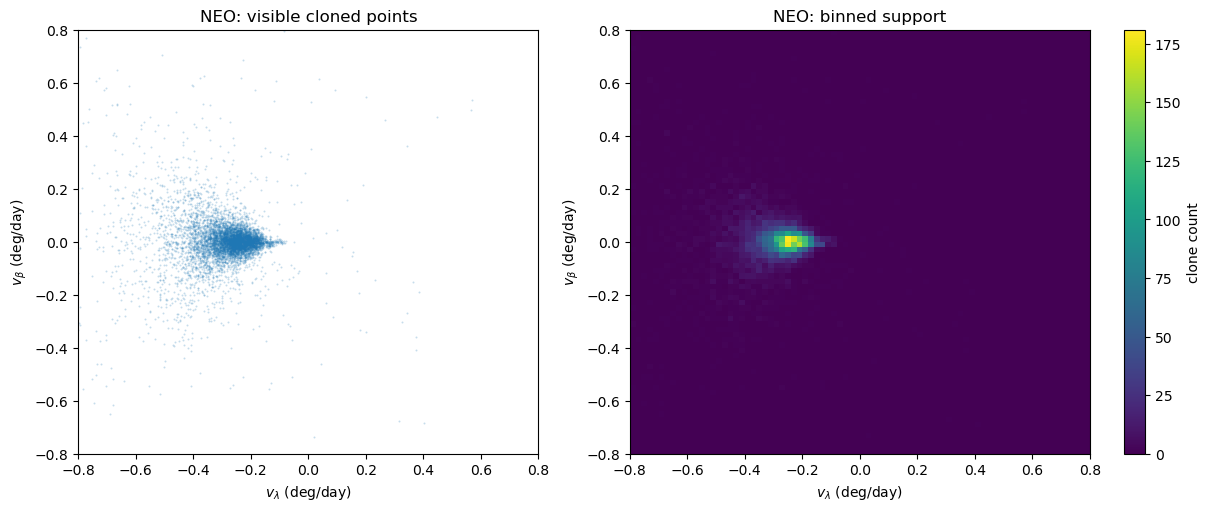

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

axes[0].scatter(
    clone_visible_df['vlam'], clone_visible_df['vbeta'],
    s=2, alpha=0.25, linewidths=0,
)
axes[0].set_title(f'{POP_TO_TEST}: visible cloned points')
axes[0].set_xlabel(r'$v_\lambda$ (deg/day)')
axes[0].set_ylabel(r'$v_\beta$ (deg/day)')
axes[0].set_xlim(*GRID_LIM)
axes[0].set_ylim(*GRID_LIM)

h = axes[1].hist2d(
    clone_visible_df['vlam'], clone_visible_df['vbeta'],
    bins=80, range=[GRID_LIM, GRID_LIM], cmap='viridis',
)
axes[1].set_title(f'{POP_TO_TEST}: binned support')
axes[1].set_xlabel(r'$v_\lambda$ (deg/day)')
axes[1].set_ylabel(r'$v_\beta$ (deg/day)')
fig.colorbar(h[3], ax=axes[1], label='clone count')

plt.show()

## 9. Build a Test Density Map

In [16]:
x_grid, y_grid, X0, Y0, grid_points = vdp.make_default_grid(
    grid_lim=GRID_LIM,
    grid_step=GRID_STEP,
)

pts = clone_visible_df[['vlam', 'vbeta']].to_numpy(dtype=float)
good_pts = np.isfinite(pts).all(axis=1)
pts = pts[good_pts]

print('Finite velocity points:', len(pts))

if len(pts) < 3:
    raise ValueError('Too few visible points for density-map diagnostic. Increase MAX_SOURCE_OBJECTS or CLONE_FACTOR_TEST.')

tree = cKDTree(pts)
k_eff = min(K_MAP_TEST, len(pts) - 1)
density_flat = vdp.evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=k_eff,
    n_d0_grid=N_D0_GRID_TEST,
    show_progress=True,
)
density_raw = density_flat.reshape(X0.shape) / CLONE_FACTOR_TEST

support_count = vdp.make_support_count_map(
    pts[:, 0], pts[:, 1], x_grid, y_grid, clone_factor=CLONE_FACTOR_TEST,
)

print('k_eff:', k_eff)
print('raw density max:', float(np.nanmax(density_raw)))
print('support max:', float(np.nanmax(support_count)))

Finite velocity points: 6867


Evaluating density map: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6561/6561 [00:09<00:00, 656.30it/s]

k_eff: 10
raw density max: 31614.128508049023
support max: 187.0


## 10. Apply the Production-Style Smoothing Passes

In [17]:
density_smoothed = density_raw.copy()
support_for_smoothing = support_count * CLONE_FACTOR_TEST if SCALE_SUPPORT_BY_CLONE_FACTOR else support_count

for pass_cfg in SMOOTH_PASSES:
    density_smoothed = vdp.smooth_density_map_by_support(
        density_smoothed,
        support_for_smoothing,
        support_threshold=pass_cfg['support_threshold'],
        sigma_pixels=pass_cfg['sigma_pixels'],
        truncate_sigma=pass_cfg['truncate_sigma'],
    )

density_delta = density_smoothed - density_raw

print('smoothing passes:', SMOOTH_PASSES)
print('support scaled by clone factor:', SCALE_SUPPORT_BY_CLONE_FACTOR)
print('smoothed density max:', float(np.nanmax(density_smoothed)))
print('median |delta|:', float(np.nanmedian(np.abs(density_delta))))

smoothing passes: [{'support_threshold': 3.0, 'sigma_pixels': 1.5, 'truncate_sigma': 5.0}, {'support_threshold': 10.0, 'sigma_pixels': 4.0, 'truncate_sigma': 5.0}]
support scaled by clone factor: True
smoothed density max: 3366.6663461620897
median |delta|: 0.0


## 11. Density Smoothing Difference Plot

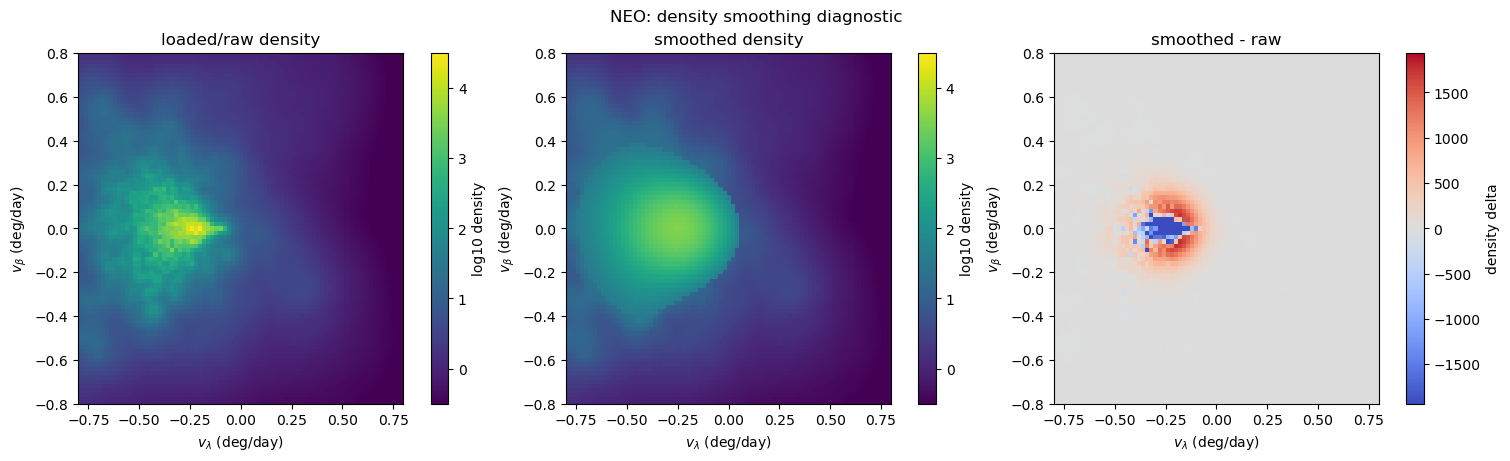

In [18]:
def density_log_map(density, floor=1e-30):
    data = np.log10(np.maximum(density, floor))
    finite = np.isfinite(data)
    if not np.any(finite):
        return data, -1.0, 1.0
    vmax = float(np.nanmax(data[finite]))
    return data, vmax - 5.0, vmax


raw_log, vmin, vmax = density_log_map(density_raw)
smooth_log, _, _ = density_log_map(density_smoothed)

lim = np.nanpercentile(np.abs(density_delta), 99.5)
if not np.isfinite(lim) or lim == 0:
    lim = 1.0

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

im0 = axes[0].pcolormesh(X0, Y0, raw_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('loaded/raw density')
fig.colorbar(im0, ax=axes[0], label='log10 density')

im1 = axes[1].pcolormesh(X0, Y0, smooth_log, shading='auto', cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('smoothed density')
fig.colorbar(im1, ax=axes[1], label='log10 density')

im2 = axes[2].pcolormesh(X0, Y0, density_delta, shading='auto', cmap='coolwarm', vmin=-lim, vmax=lim)
axes[2].set_title('smoothed - raw')
fig.colorbar(im2, ax=axes[2], label='density delta')

for ax in axes:
    ax.set_xlim(*GRID_LIM)
    ax.set_ylim(*GRID_LIM)
    ax.set_xlabel(r'$v_\lambda$ (deg/day)')
    ax.set_ylabel(r'$v_\beta$ (deg/day)')

fig.suptitle(f'{POP_TO_TEST}: density smoothing diagnostic')
plt.show()

## 12. Pull Orbital Elements from a Region in the Density Map

Use this pattern to inspect the cloned orbital elements contributing to any velocity-space region.

In [19]:
REGION_CENTER = (-0.25, 0.0)
REGION_HALF_WIDTH = 0.05

region_rows = clone_visible_df[
    (np.abs(clone_visible_df['vlam'] - REGION_CENTER[0]) <= REGION_HALF_WIDTH) &
    (np.abs(clone_visible_df['vbeta'] - REGION_CENTER[1]) <= REGION_HALF_WIDTH)
].copy()

print('Region center:', REGION_CENTER)
print('Rows in region:', len(region_rows))
region_rows[MAP_INPUT_COLS].head(30)

Region center: (-0.25, 0.0)
Rows in region: 2653


,parent_row,parent_OID,a,e,i,node,argperi,t_p,H,ra_deg,dec_deg,lam_deg,beta_deg,vlam,vbeta,sky_sep_deg
1,3,S0000hB9a,2.133839,0.835801,20.211002,83.162415,323.335327,60496.250000,23.255,236.203261,-5.490802,235.211507,13.960465,-0.279263,-0.009865,15.253297
8,5,S0000TiNa,2.462124,0.904189,33.804283,46.583328,6.151260,60592.875000,24.676,225.344067,-18.803060,228.271879,-1.596765,-0.239850,-0.022276,1.756513
11,5,S0000TiNa,2.462124,0.904189,33.804283,46.583328,9.259193,60554.285156,24.676,229.187062,-22.979792,232.863988,-4.647504,-0.236549,-0.023182,6.038804
13,7,S00002Tya,1.820014,0.838776,12.447192,104.095383,318.250977,60705.214844,21.016,250.560791,-10.806370,250.524723,11.328321,-0.293776,0.014144,24.194421
15,8,S0000RO1a,3.067356,0.618321,15.102691,20.697529,55.190182,60645.703125,24.642,220.761769,-25.188848,226.064921,-8.943752,-0.210583,-0.020114,9.410520
18,9,S0000HTMa,2.795065,0.666762,12.706890,93.801392,286.389282,60031.953125,24.389,216.699785,-0.033352,214.378119,13.720535,-0.209080,-0.023480,19.951019
19,10,S00008n0a,2.571519,0.607460,5.711600,145.032974,280.074585,60757.097656,22.333,212.727193,-5.176575,212.311915,7.550314,-0.225442,-0.011124,18.275795
20,13,S0000mv8a,2.033225,0.786717,9.694945,281.216522,125.927322,60448.664062,23.560,242.599318,-30.166222,246.246771,-8.958584,-0.283118,-0.008238,19.368336
21,14,S0000rJpa,2.247345,0.544222,9.999357,346.649780,81.451035,60586.171875,23.820,247.235690,-35.464993,251.087818,-13.508340,-0.222815,-0.036073,25.710240
22,14,S0000rJpa,2.247345,0.544222,9.999357,346.649780,69.985901,60738.109375,23.820,204.535460,-21.981492,210.765624,-10.967274,-0.241905,0.006021,21.185248


In [20]:
region_rows[['a', 'e', 'i', 'node', 'argperi', 't_p', 'H', 'vlam', 'vbeta']].describe().T

,count,mean,std,min,25%,50%,75%,max
a,2653.0,2.410367,0.324701,1.518477,2.181402,2.377758,2.604996,4.956533
e,2653.0,0.624061,0.140556,0.311641,0.514050,0.600856,0.729392,0.996949
i,2653.0,11.864716,8.781505,0.193203,6.188843,9.599685,14.797390,77.144669
node,2653.0,175.140975,103.202580,0.011130,81.292992,174.270966,260.152374,359.674164
argperi,2653.0,178.563866,104.132721,0.079315,89.843575,178.982590,266.962921,359.746124
t_p,2653.0,60456.255452,337.376468,57434.437500,60267.773438,60525.933594,60702.292969,61139.496094
H,2653.0,23.806553,1.149462,16.698000,23.310000,24.147000,24.657000,24.999000
vlam,2653.0,-0.248219,0.027165,-0.299804,-0.269973,-0.247262,-0.225771,-0.200092
vbeta,2653.0,-0.000185,0.023953,-0.049979,-0.018028,-0.000022,0.017361,0.049977


In [288]:
from sklearn.mixture import GaussianMixture

def cloneGMM(df, Nclones, Ncomp=100):

    # repack/rescale
    X = np.column_stack([
        df['a'],
        df['q'],
        np.sin(df['i']/180*np.pi),
        np.cos(df['i']/180*np.pi),
        np.sin(df['node']/180*np.pi),
        np.cos(df['node']/180*np.pi),
        np.sin(df['argperi']/180*np.pi),
        np.cos(df['argperi']/180*np.pi),
        df['t_p'],
        df['H'],
        df['node'],
        df['argperi'],
        df['i'],
        df['e']
    ])
    
    # set up GMM
    gmm = GaussianMixture(
        n_components=Ncomp,
        covariance_type='full',
        random_state=0
    )
    # fit GMM 
    gmm.fit(X)
       
    # generate cloned sample
    Xsim, labels = gmm.sample(Nclones)    
        
    # repack   
    a_sim = Xsim[:,0]
    q_sim = Xsim[:,1]
    e_sim = Xsim[:,13]
    # node
    Xsim[:,10] = (np.pi+np.arctan2(Xsim[:,4], Xsim[:,5]))/2/np.pi*360
    # argperi
    Xsim[:,11] = (np.pi+np.arctan2(Xsim[:,6], Xsim[:,7]))/2/np.pi*360
    # inclination
    Xsim[:,12] = (0*np.pi+np.arctan2(Xsim[:,2], Xsim[:,3]))/2/np.pi*360   
        
    mask = (
        (a_sim > 0) &
        (e_sim >= 0) &
        (e_sim < 1.0) &
        (q_sim >= 0) &
        (q_sim < 1.3) &
        (Xsim[:,9] < np.max(df['H'])) &
        (Xsim[:,12] >= 0) &
        (Xsim[:,12] < np.max(df['i'])) 
    )

    Xsim = Xsim[mask]
        
    return Xsim 

In [289]:
inputDF = df_neo
# inputDF = df_trojan

In [290]:
Xsim = cloneGMM(inputDF, Nclones=1_000_000, Ncomp=500)

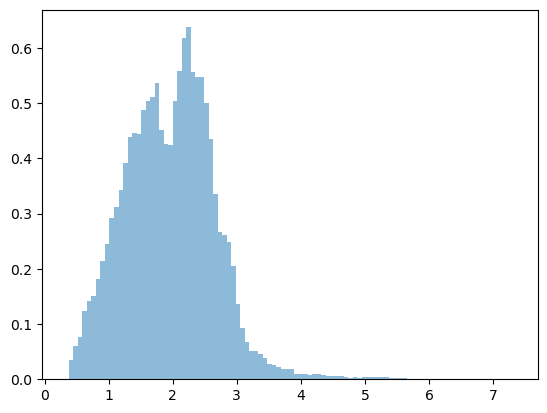

In [291]:
h = plt.hist(inputDF['a'], bins=100, density=True, alpha=0.5) 

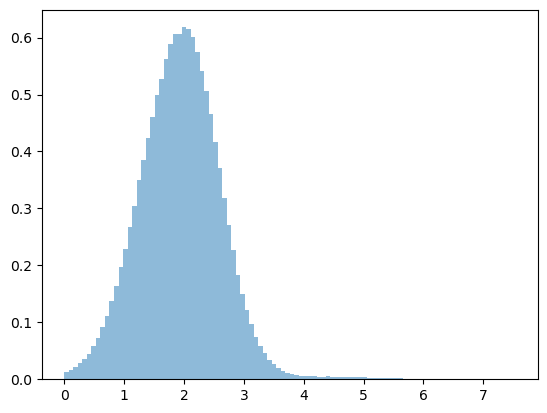

In [292]:
hs = plt.hist(Xsim[:,0], bins=100, density=True, alpha=0.5)

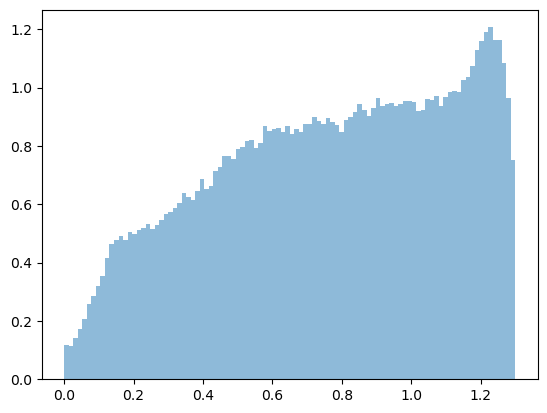

In [293]:
h = plt.hist(inputDF['q'], bins=100, density=True, alpha=0.5) 

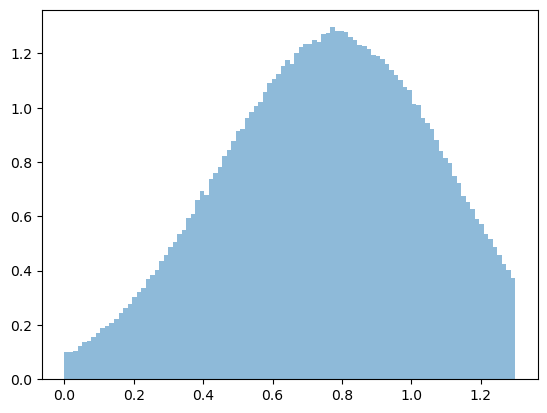

In [294]:
hs = plt.hist(Xsim[:,1], bins=100, density=True, alpha=0.5)

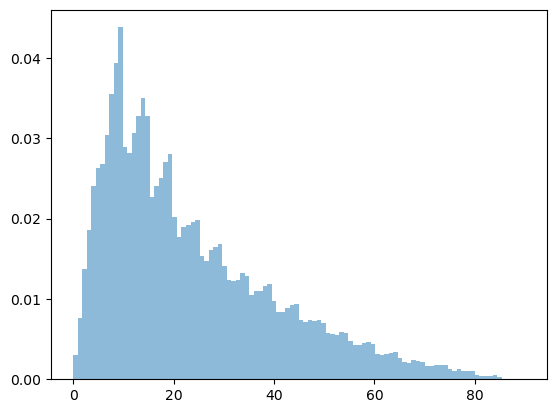

In [295]:
h = plt.hist(inputDF['i'], bins=100, density=True, alpha=0.5) 

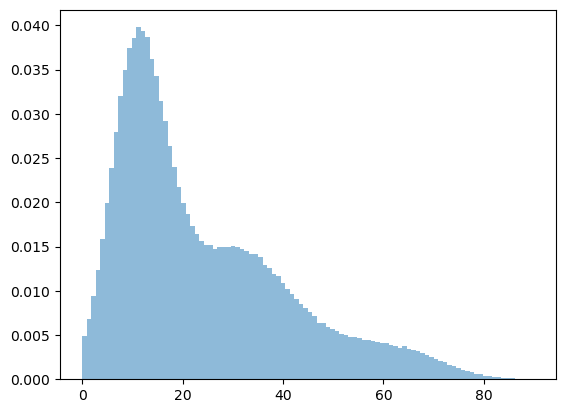

In [296]:
hs = plt.hist(Xsim[:,12], bins=100, density=True, alpha=0.5)

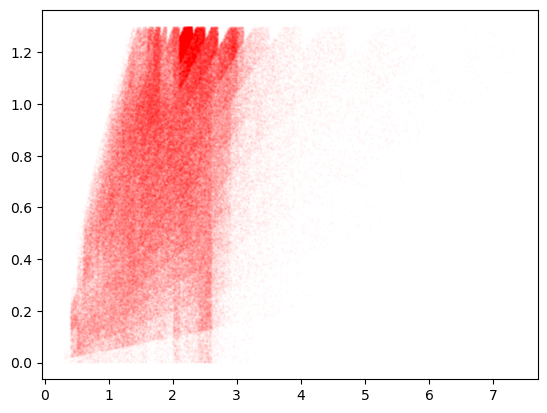

In [297]:
ax = plt.figure().add_subplot(111)
ax.scatter(inputDF['a'], inputDF['q'],  s=1,    alpha=0.01  , c='red')

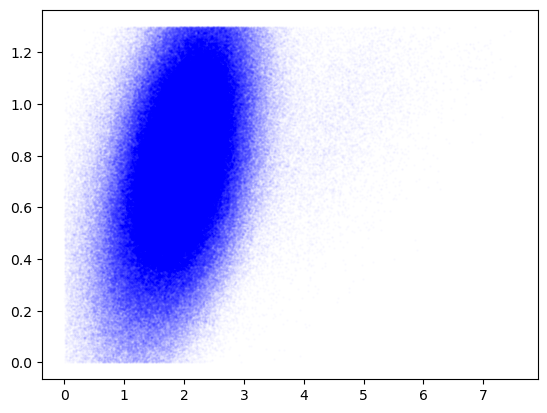

In [298]:
ax = plt.figure().add_subplot(111)
ax.scatter(Xsim[:,0], Xsim[:,1],  s=1,    alpha=0.01  , c='blue')

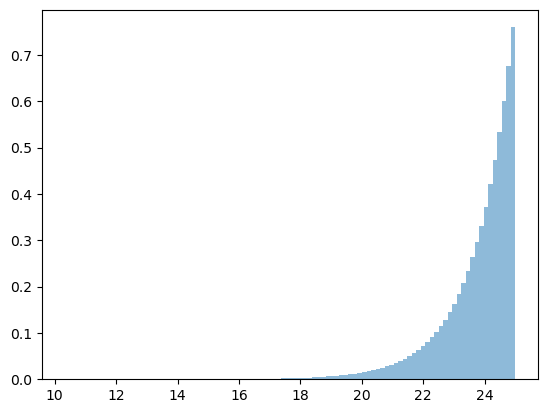

In [299]:
h = plt.hist(inputDF['H'], bins=100, density=True, alpha=0.5) 

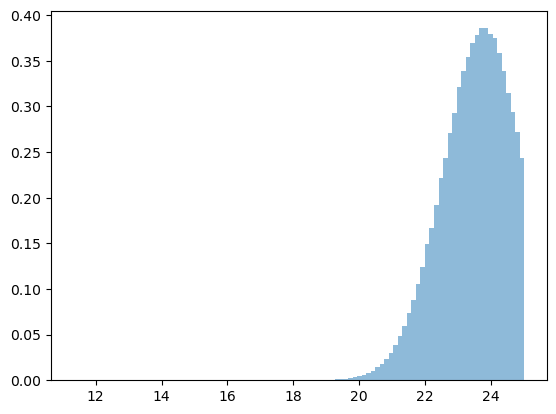

In [300]:
h = plt.hist(Xsim[:,9], bins=100, density=True, alpha=0.5) 

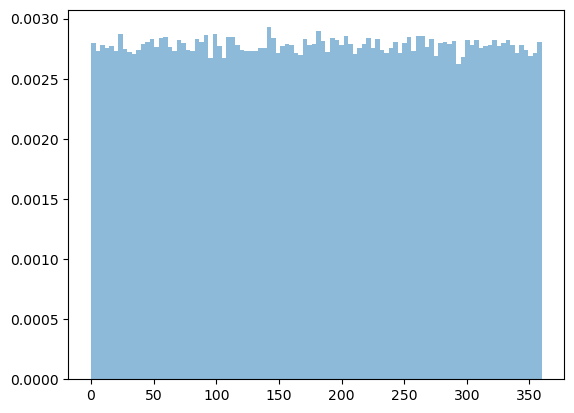

In [301]:
h = plt.hist(inputDF['node'], bins=100, density=True, alpha=0.5) 

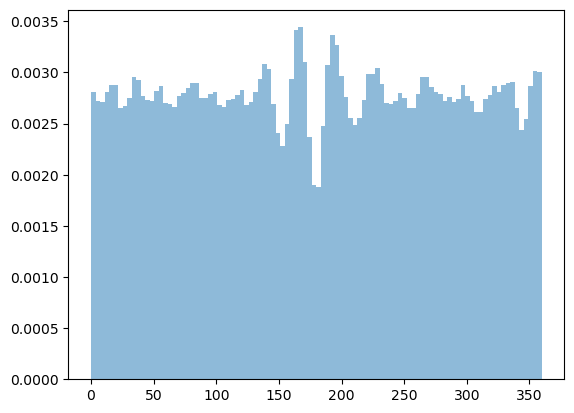

In [302]:
hs = plt.hist(Xsim[:,10], bins=100, density=True, alpha=0.5)

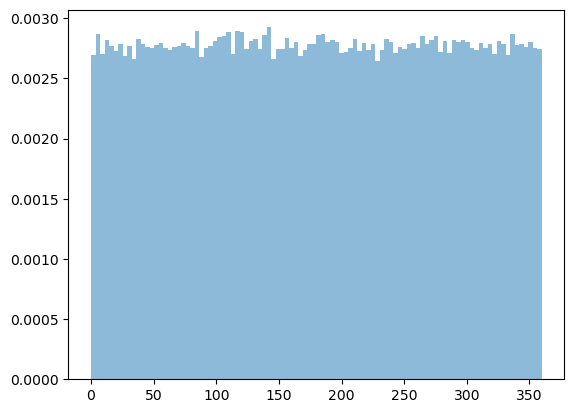

In [303]:
h = plt.hist(inputDF['argperi'], bins=100, density=True, alpha=0.5) 

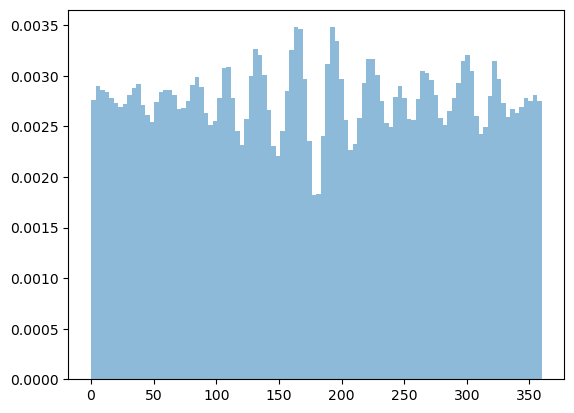

In [304]:
hs = plt.hist(Xsim[:,11], bins=100, density=True, alpha=0.5)

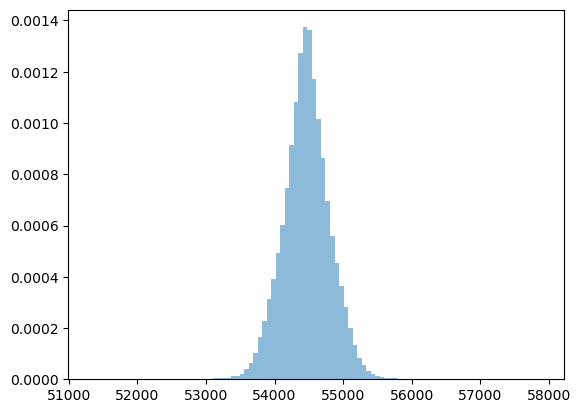

In [305]:
h = plt.hist(inputDF['t_p'], bins=100, density=True, alpha=0.5) 

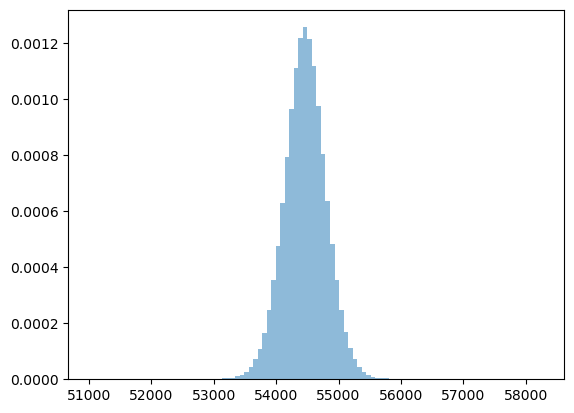

In [306]:
hs = plt.hist(Xsim[:,8], bins=100, density=True, alpha=0.5)

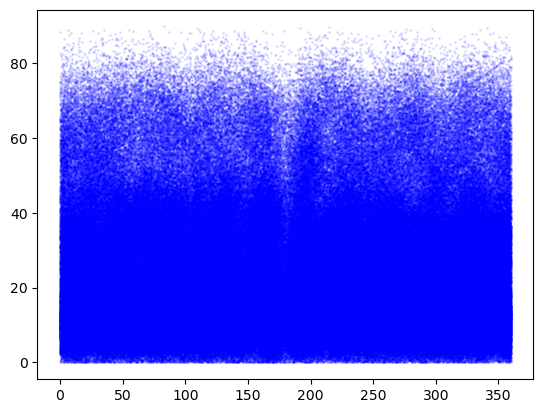

In [307]:
ax = plt.figure().add_subplot(111)
ax.scatter(Xsim[:,10], Xsim[:,12],  s=1,    alpha=0.1,c='blue')

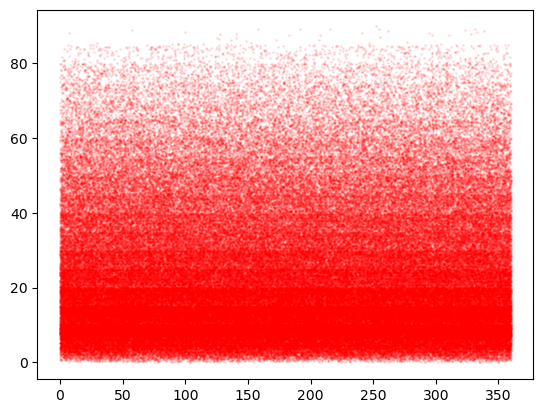

In [308]:
ax = plt.figure().add_subplot(111)
ax.scatter(inputDF['node'], inputDF['i'],  s=1,    alpha=0.1  ,  c='red')